In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import networkx as nx

# 2D NETWORK

In [2]:
import subprocess
import numpy as np
from pathlib import Path

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.3 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.76 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 20 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

filename = fcn.run_2D_tune_positions(parameters2D)

Configuration already exists: 2D_initial_configurations/2D_neurons_params_agg_nc20_s0.0800_L3.0_rho250_l0.76.txt


Gini coefficient: 0.7749638392857143


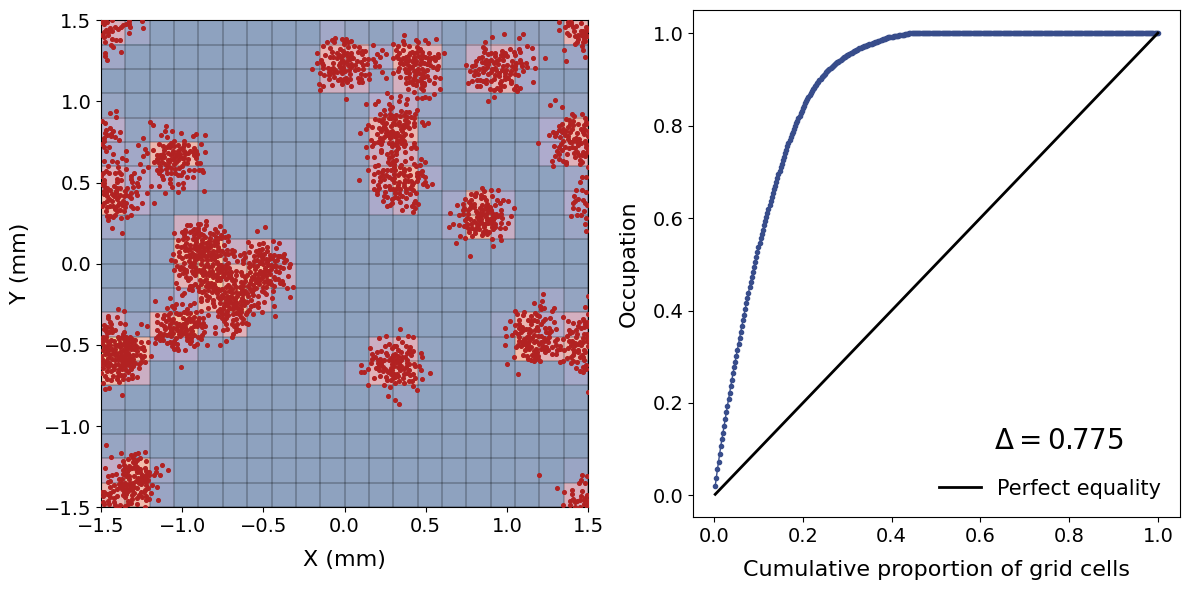

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.neuron_map_gini2D(filename, parameters2D)

In [ ]:
import subprocess
import numpy as np

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

alphas = [0.25]
# alphas = np.arange(0.0, 1.01, 0.01)

output_filenames = fcn.create_network2D(parameters2D, alphas)

Configuration already exists: 2D_created_networks\2D_adjacency_matrix_agg_nc20_s0.0800_L3.0_rho250_l0.76_a0.250.txt


Loading adjacency matrix from: 2D_created_networks/2D_adjacency_matrix_agg_nc20_s0.0800_L3.0_rho250_l0.76_a0.250.txt


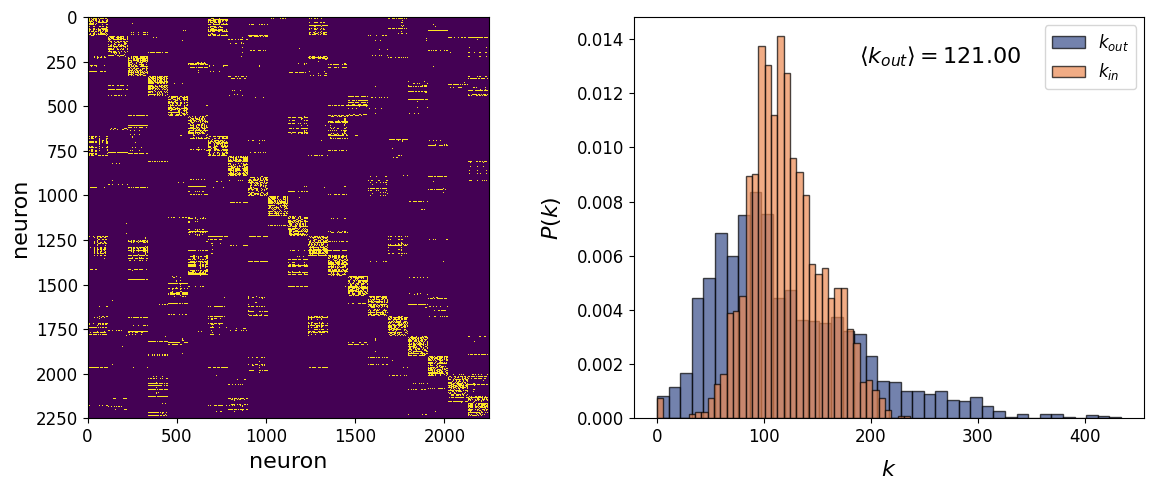

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

filename = output_filenames[0]
print("Loading adjacency matrix from:", filename)

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

A = load_A(filename)

# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [79]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.3 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 1.0 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 20 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.30, 50)
Gini_values = []

filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = s

        filename = fcn.run_2D_tune_positions(parameters2D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r")

L = parameters2D["L"]
xmin = ymin = -L/2
xmax = ymax = L/2
n_grid = 20

def Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax):
    H, _, _ = np.histogram2d(X, Y, bins=n_grid, range=[[xmin,xmax],[ymin,ymax]])
    bin_sum = H.sum()

    sum_gini = 0.0
    H_flat = H.flatten()
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat))

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini/bin_sum

    bins = np.arange(1, len(H_flat)+1)
    bins = bins/len(H_flat)

    area_between = np.trapezoid(G-bins, bins)
    Gini = 2*area_between
    return Gini

for filename in filenames_Gini:
    X, Y, _, _, _ = fcn.load_neuron_params(filename)
    Gini = Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax)
    Gini_values.append(Gini)

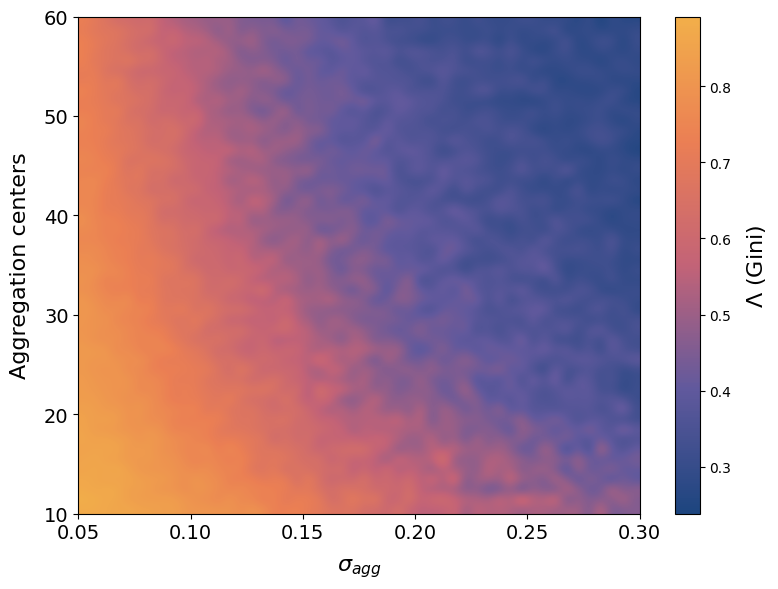

In [87]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

Gini_map = np.array(Gini_values).reshape(len(number_of_centers), len(base_sigmas))

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

# 3D NETWORK

In [18]:
import subprocess
import numpy as np
from pathlib import Path
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.7 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 0 # Control parameter for the aggregation of neurons
n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.05 # Base standard deviation for aggregation centers (mm)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma
}

filename = fcn.run_3D_tune_positions(parameters3D)

Configuration already exists: 3D_initial_configurations/3D_neurons_params_random_L3.0_rho250_l0.70.txt


In [111]:
%matplotlib inline

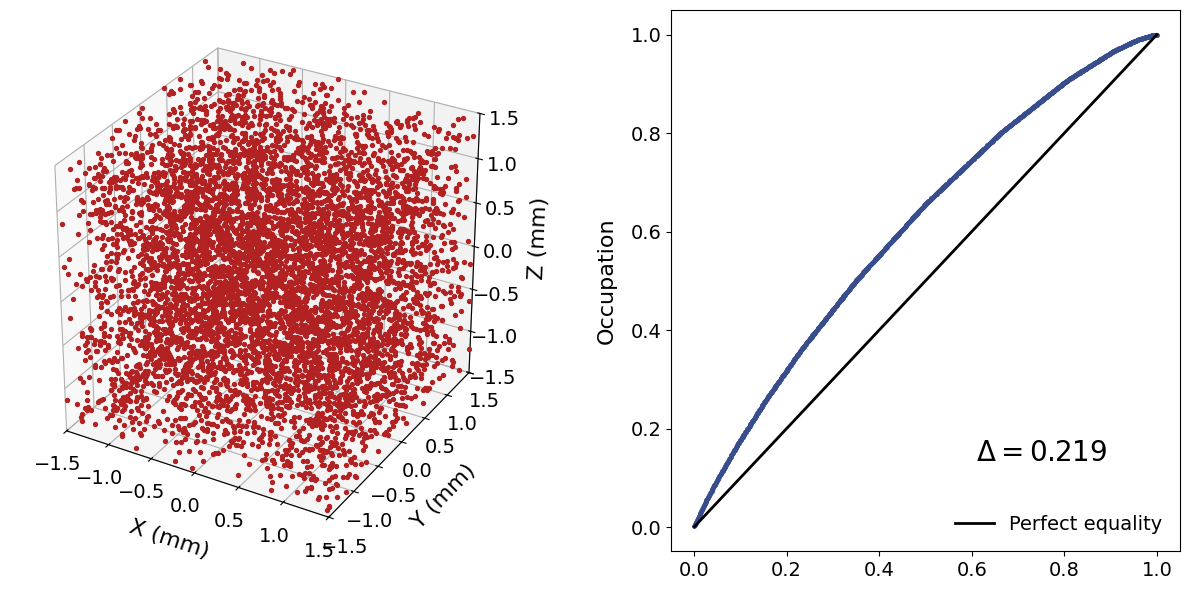

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.neuron_map_gini3D(filename, parameters3D)

In [20]:
import subprocess
import numpy as np

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

alphas = [0.25]
# alphas = np.arange(0.0, 1.01, 0.01)

output_filenames = fcn.create_network3D(parameters3D, alphas)

Configuration already exists: 3D_created_networks\3D_adjacency_matrix_random_L3.0_rho250_l0.70_a0.250.txt


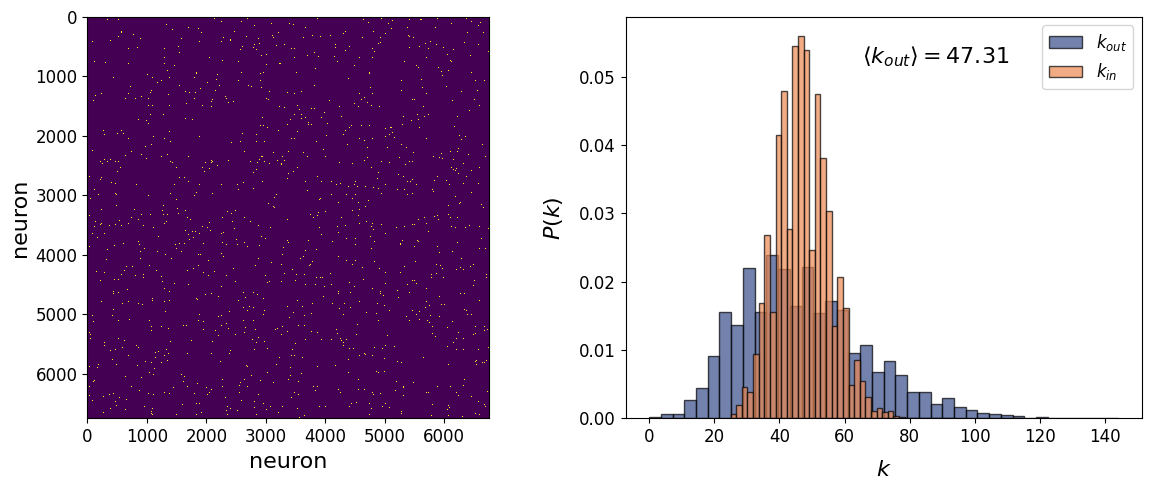

In [21]:
import numpy as np
import matplotlib.pyplot as plt

filename = output_filenames[0]

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

A = load_A(filename)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')


# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()